# Regime Detection Comparison: MMD vs BOCPD

Comparing nonparametric (MMD) and Bayesian (BOCPD) approaches to detecting
regime changes in SPY daily returns (2018-2024).

**2x2 design**: each method is run on both univariate (log returns) and
multivariate (log OHLCV) signals to separate the framework effect from the
feature effect.

## Configuration

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

SAVE_FIGURES = os.environ.get("SAVE_FIGURES", "0") == "1"
FIGURES_DIR = "../figures"

BOCPD_R_MAX = 600
BOCPD_HAZARD_LAMBDA = 100

KNOWN_EVENTS = {
    "COVID crash": ("2020-02-19", "2020-03-23"),
    "COVID recovery": ("2020-03-24", "2020-08-01"),
    "2022 drawdown": ("2022-01-03", "2022-10-12"),
    "2022 bottom": ("2022-10-12", "2022-12-31"),
    "2023 acceleration": ("2023-10-01", "2023-12-31"),
}


def save_fig(fig, name):
    if SAVE_FIGURES:
        os.makedirs(FIGURES_DIR, exist_ok=True)
        fig.savefig(
            os.path.join(FIGURES_DIR, name), dpi=200, bbox_inches="tight"
        )

---
## S1 -- Data Pipeline

Fetch SPY via finfeatures, extract univariate and multivariate signal
variants, standardize.

In [2]:
from finfeatures.sources import YFinanceSource

source = YFinanceSource()
raw = source.fetch("SPY", start="2018-01-01", end="2024-01-01")
print(f"Raw data: {raw.shape[0]} rows, columns: {list(raw.columns)}")
raw.head()

Raw data: 1509 rows, columns: ['open', 'high', 'low', 'close', 'volume']


,open,high,low,close,volume
date,,,,,
2018-01-02,236.387393,237.243486,235.999060,237.208176,86655700
2018-01-03,237.375914,238.858652,237.375914,238.708603,90070400
2018-01-04,239.352816,240.200075,238.770317,239.714645,80636400
2018-01-05,240.509129,241.435817,240.014892,241.312271,83524000
2018-01-08,241.215067,241.912305,240.923831,241.753448,57319200


In [3]:
# Construct signals from raw OHLCV
# Univariate: log returns
log_returns = np.log(raw["close"] / raw["close"].shift(1)).dropna()

# Multivariate: log OHLCV (5 features)
log_ohlcv = pd.DataFrame(
    {
        "log_open": np.log(raw["open"]),
        "log_high": np.log(raw["high"]),
        "log_low": np.log(raw["low"]),
        "log_close": np.log(raw["close"]),
        "log_volume": np.log(raw["volume"]),
    },
    index=raw.index,
).dropna()

# Align indices (log_returns has one fewer row due to differencing)
common_idx = log_returns.index.intersection(log_ohlcv.index)
log_returns = log_returns.loc[common_idx]
log_ohlcv = log_ohlcv.loc[common_idx]

# Standardize
scaler_uni = StandardScaler()
signal_uni = scaler_uni.fit_transform(log_returns.values.reshape(-1, 1)).ravel()

scaler_multi = StandardScaler()
signal_multi = scaler_multi.fit_transform(log_ohlcv.values)

dates_index = common_idx

print(f"Univariate signal:   shape {signal_uni.shape}")
print(f"Multivariate signal: shape {signal_multi.shape}")
print(f"Date range: {dates_index[0].date()} to {dates_index[-1].date()}")

Univariate signal:   shape (1508,)
Multivariate signal: shape (1508, 5)
Date range: 2018-01-03 to 2023-12-29


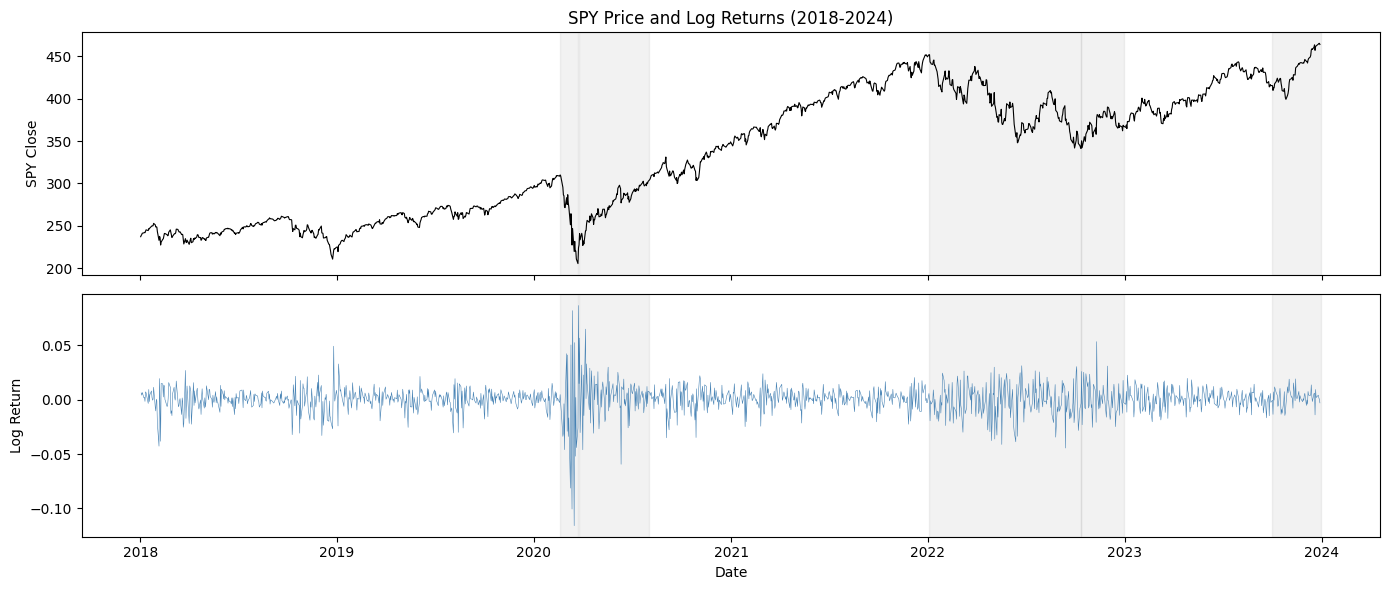

In [4]:
# Sanity check: price and log returns
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(raw.index, raw["close"], color="black", linewidth=0.8)
axes[0].set_ylabel("SPY Close")
axes[0].set_title("SPY Price and Log Returns (2018-2024)")

axes[1].plot(dates_index, log_returns.values, color="steelblue", linewidth=0.4)
axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")

# Shade known events
for label, (start, end) in KNOWN_EVENTS.items():
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color="gray")

plt.tight_layout()
save_fig(fig, "sanity_check.png")
plt.show()

---
## S2 -- Detection Runs

Four configurations in the 2x2 design. Each is timed and produces a
consistent result dict.

In [5]:
# Container for all results
all_results = []

### 2a: BOCPD -- Univariate (log returns)

In [6]:
from bocpd import (
    BOCPD,
    ConstantHazard,
    UnivariateNormalNIG,
    extract_change_points_with_bounds,
)

t0 = time.perf_counter()

detector_bocpd_uni = BOCPD(
    model_factory=lambda: UnivariateNormalNIG(
        mu0=0.0, kappa0=0.1, alpha0=1.0, beta0=1.0
    ),
    hazard_fn=ConstantHazard(lam=BOCPD_HAZARD_LAMBDA),
    r_max=BOCPD_R_MAX,
)
bocpd_uni_raw = detector_bocpd_uni.run(signal_uni)
bocpd_uni_boundaries = extract_change_points_with_bounds(
    bocpd_uni_raw, credible_mass=0.90
)

runtime_bocpd_uni = time.perf_counter() - t0

# Extract expected run length — this is what drives boundary detection.
# P(changepoint) with constant hazard is ~1/lambda (nearly flat), so
# expected run length is the more informative continuous signal.
bocpd_uni_erl = bocpd_uni_raw["expected_run_length"]

all_results.append(
    {
        "name": "BOCPD univariate",
        "method": "bocpd",
        "features": "univariate",
        "boundaries": [
            dates_index[b["index"]] for b in bocpd_uni_boundaries
        ],
        "continuous_signal": pd.Series(bocpd_uni_erl, index=dates_index),
        "signal_label": "E[run length]",
        "runtime_seconds": runtime_bocpd_uni,
        "config": {"hazard_lambda": BOCPD_HAZARD_LAMBDA, "kappa0": 0.1, "alpha0": 1.0, "beta0": 1.0, "r_max": BOCPD_R_MAX},
    }
)

print(f"BOCPD univariate: {len(bocpd_uni_boundaries)} boundaries, {runtime_bocpd_uni:.2f}s")
for b in bocpd_uni_boundaries:
    print(f"  t={b['index']} ({dates_index[b['index']].date()}), "
          f"90% CI: [{b['lower']}, {b['upper']}], severity: {b['severity']:.3f}")

BOCPD univariate: 9 boundaries, 5.58s
  t=22 (2018-02-05), 90% CI: [15, 25], severity: 0.879
  t=194 (2018-10-10), 90% CI: [66, 193], severity: 0.990
  t=340 (2019-05-13), 90% CI: [252, 335], severity: 0.790
  t=672 (2020-09-03), 90% CI: [624, 671], severity: 0.966
  t=754 (2020-12-31), 90% CI: [613, 730], severity: 0.493
  t=1029 (2022-02-03), 90% CI: [966, 1025], severity: 0.801
  t=1164 (2022-08-18), 90% CI: [974, 1130], severity: 0.152
  t=1223 (2022-11-10), 90% CI: [973, 1086], severity: 0.455
  t=1334 (2023-04-24), 90% CI: [1223, 1312], severity: 0.645


### 2b: BOCPD -- Multivariate (log OHLCV)

In [7]:
from bocpd import MultivariateNormalNIW

t0 = time.perf_counter()

D = signal_multi.shape[1]  # 5

detector_bocpd_multi = BOCPD(
    model_factory=lambda: MultivariateNormalNIW(
        dim=D,
        mu0=np.zeros(D),
        kappa0=0.1,
        nu0=float(D + 2),
        Psi0=np.eye(D),
    ),
    hazard_fn=ConstantHazard(lam=BOCPD_HAZARD_LAMBDA),
    r_max=BOCPD_R_MAX,
)
bocpd_multi_raw = detector_bocpd_multi.run(signal_multi)
bocpd_multi_boundaries = extract_change_points_with_bounds(
    bocpd_multi_raw, credible_mass=0.90
)

runtime_bocpd_multi = time.perf_counter() - t0

# Extract expected run length
bocpd_multi_erl = bocpd_multi_raw["expected_run_length"]

all_results.append(
    {
        "name": "BOCPD multivariate",
        "method": "bocpd",
        "features": "multivariate",
        "boundaries": [
            dates_index[b["index"]] for b in bocpd_multi_boundaries
        ],
        "continuous_signal": pd.Series(bocpd_multi_erl, index=dates_index),
        "signal_label": "E[run length]",
        "runtime_seconds": runtime_bocpd_multi,
        "config": {"hazard_lambda": BOCPD_HAZARD_LAMBDA, "kappa0": 0.1, "nu0": D + 2, "r_max": BOCPD_R_MAX},
    }
)

print(f"BOCPD multivariate: {len(bocpd_multi_boundaries)} boundaries, {runtime_bocpd_multi:.2f}s")
for b in bocpd_multi_boundaries:
    print(f"  t={b['index']} ({dates_index[b['index']].date()}), "
          f"90% CI: [{b['lower']}, {b['upper']}], severity: {b['severity']:.3f}")

BOCPD multivariate: 4 boundaries, 1.03s
  t=542 (2020-03-02), 90% CI: [532, 538], severity: 0.989
  t=599 (2020-05-21), 90% CI: [596, 602], severity: 1.000
  t=1199 (2022-10-07), 90% CI: [598, 738], severity: 1.000
  t=1445 (2023-10-02), 90% CI: [1382, 1439], severity: 0.886


### 2c: MMD -- Univariate (log returns)

In [8]:
from kta import rbf
from regime_detection import (
    find_regime_boundaries,
    results_to_dataframe,
    sliding_window_mmd,
)

t0 = time.perf_counter()

signal_uni_2d = signal_uni.reshape(-1, 1)
sigma_uni = np.median(np.abs(signal_uni_2d - np.median(signal_uni_2d)))
gamma_uni = 1.0 / (2 * sigma_uni**2)

mmd_uni_raw = sliding_window_mmd(
    data=signal_uni_2d,
    kernel_fn=rbf,
    kernel_params={"gamma": gamma_uni},
    window=30,
    step=5,
    n_permutations=500,
)
mmd_uni_df = results_to_dataframe(mmd_uni_raw, dates_index)
mmd_uni_boundaries = find_regime_boundaries(mmd_uni_df, threshold=10.0)

runtime_mmd_uni = time.perf_counter() - t0

all_results.append(
    {
        "name": "MMD univariate",
        "method": "mmd",
        "features": "univariate",
        "boundaries": mmd_uni_boundaries,
        "continuous_signal": mmd_uni_df["std_from_null"],
        "signal_label": "z-score from null",
        "runtime_seconds": runtime_mmd_uni,
        "config": {"window": 30, "step": 5, "n_permutations": 500, "gamma": gamma_uni, "threshold": 10.0},
    }
)

print(f"MMD univariate: {len(mmd_uni_boundaries)} boundaries, {runtime_mmd_uni:.2f}s")

MMD univariate: 1 boundaries, 7.62s


### 2d: MMD -- Multivariate (log OHLCV)

In [9]:
t0 = time.perf_counter()

sigma_multi_med = np.median(np.abs(signal_multi - np.median(signal_multi)))
gamma_multi = 1.0 / (2 * sigma_multi_med**2)

mmd_multi_raw = sliding_window_mmd(
    data=signal_multi,
    kernel_fn=rbf,
    kernel_params={"gamma": gamma_multi},
    window=30,
    step=5,
    n_permutations=500,
)
mmd_multi_df = results_to_dataframe(mmd_multi_raw, dates_index)
mmd_multi_boundaries = find_regime_boundaries(mmd_multi_df, threshold=10.0)

runtime_mmd_multi = time.perf_counter() - t0

all_results.append(
    {
        "name": "MMD multivariate",
        "method": "mmd",
        "features": "multivariate",
        "boundaries": mmd_multi_boundaries,
        "continuous_signal": mmd_multi_df["std_from_null"],
        "signal_label": "z-score from null",
        "runtime_seconds": runtime_mmd_multi,
        "config": {"window": 30, "step": 5, "n_permutations": 500, "gamma": gamma_multi, "threshold": 10.0},
    }
)

print(f"MMD multivariate: {len(mmd_multi_boundaries)} boundaries, {runtime_mmd_multi:.2f}s")

MMD multivariate: 43 boundaries, 8.30s


---
## S3 -- Results and Visualization

### Main panel figure

Four vertically stacked panels with shared date axis:
1. Price + boundary lines (all four configs)
2. MMD z-scores (uni + multi)
3. BOCPD expected run length (uni + multi) -- sharp drops indicate changepoints
4. Known events as shaded regions

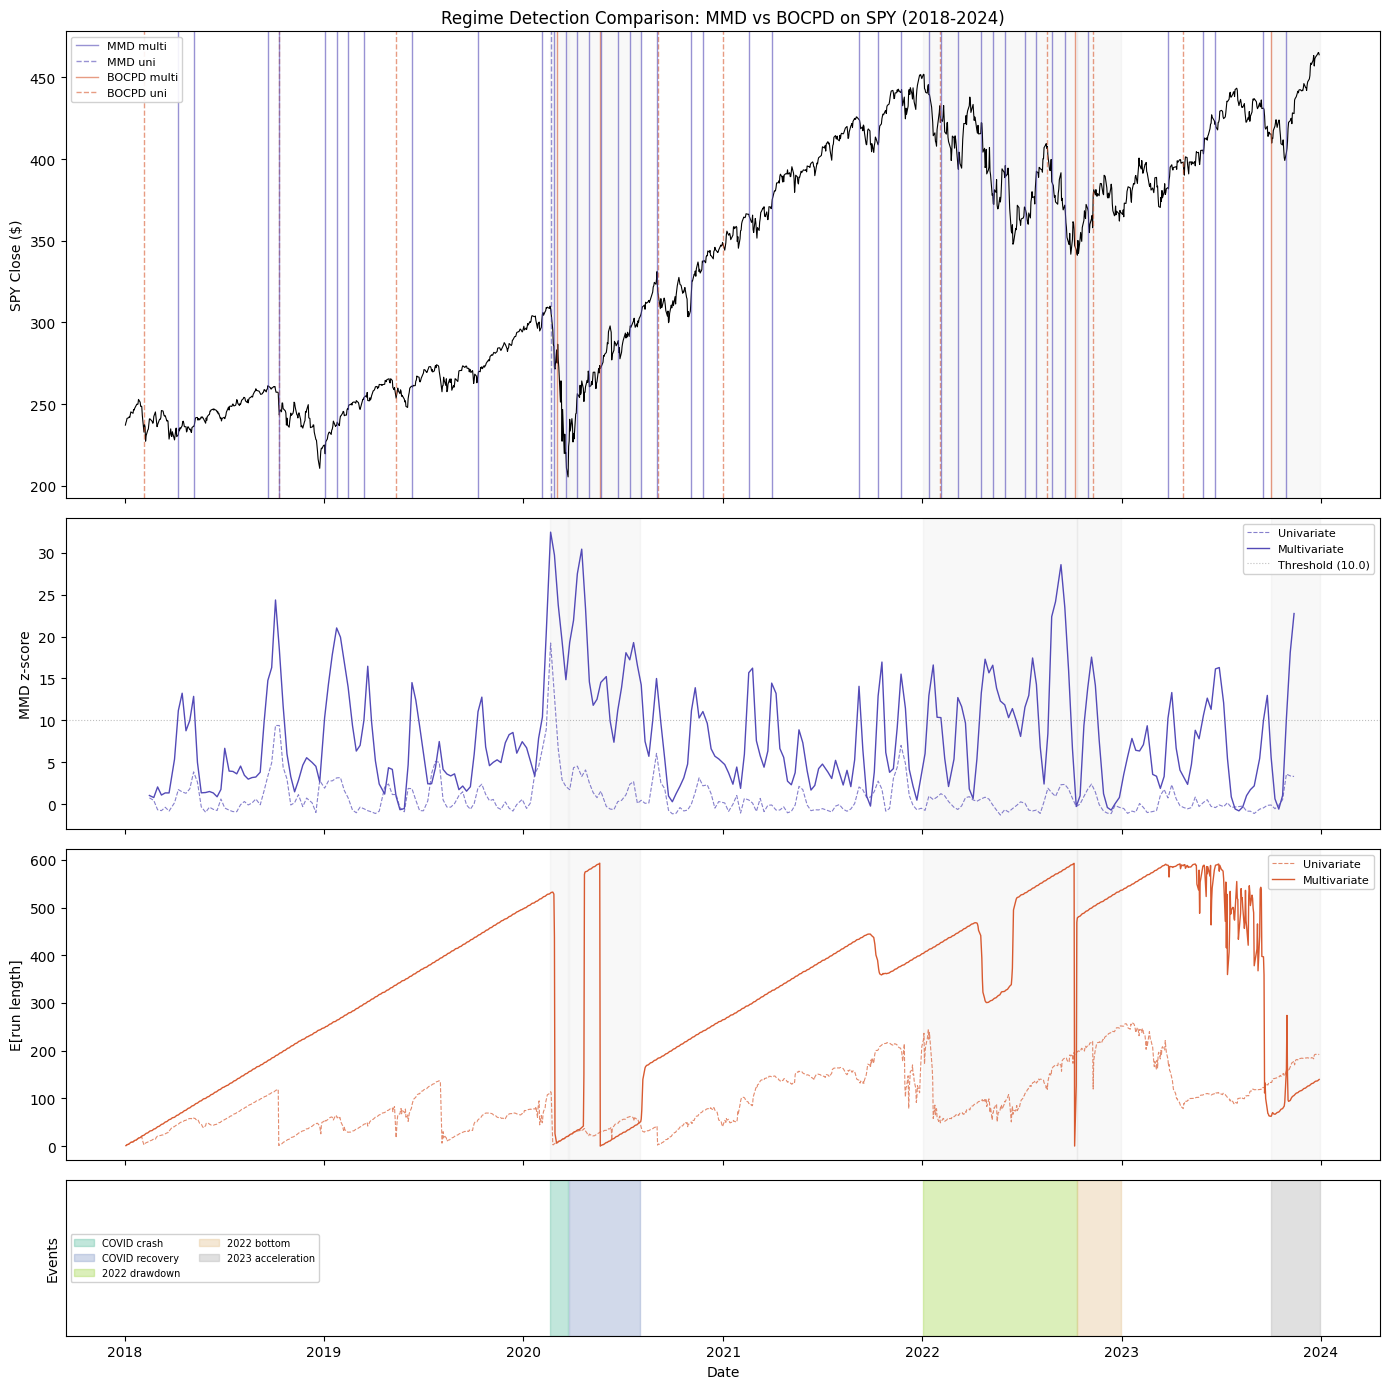

In [10]:
COLOR_MMD = "#534AB7"
COLOR_BOCPD = "#D85A30"

STYLE_MAP = {
    "MMD multivariate": {"color": COLOR_MMD, "linestyle": "-", "label": "MMD multi"},
    "MMD univariate": {"color": COLOR_MMD, "linestyle": "--", "label": "MMD uni"},
    "BOCPD multivariate": {"color": COLOR_BOCPD, "linestyle": "-", "label": "BOCPD multi"},
    "BOCPD univariate": {"color": COLOR_BOCPD, "linestyle": "--", "label": "BOCPD uni"},
}

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2, 2, 1]})

# Panel 1: Price with boundary lines
axes[0].plot(raw.index, raw["close"], color="black", linewidth=0.8)
axes[0].set_ylabel("SPY Close ($)")
axes[0].set_title("Regime Detection Comparison: MMD vs BOCPD on SPY (2018-2024)")

for r in all_results:
    style = STYLE_MAP[r["name"]]
    for bd in r["boundaries"]:
        axes[0].axvline(bd, color=style["color"], linestyle=style["linestyle"],
                        alpha=0.6, linewidth=1.0)

# Legend with proxy artists (avoids distorting x-axis)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=s["color"], linestyle=s["linestyle"], linewidth=1.0,
           alpha=0.6, label=s["label"])
    for s in STYLE_MAP.values()
]
axes[0].legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.9)

# Panel 2: MMD z-scores
axes[1].plot(mmd_uni_df.index, mmd_uni_df["std_from_null"],
             color=COLOR_MMD, linestyle="--", linewidth=0.8, alpha=0.7,
             label="Univariate")
axes[1].plot(mmd_multi_df.index, mmd_multi_df["std_from_null"],
             color=COLOR_MMD, linestyle="-", linewidth=1.0,
             label="Multivariate")
axes[1].axhline(10.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5,
                label="Threshold (10.0)")
axes[1].set_ylabel("MMD z-score")
axes[1].legend(loc="upper right", fontsize=8, framealpha=0.9)

# Panel 3: BOCPD expected run length (drops indicate changepoints)
bocpd_uni_signal = all_results[0]["continuous_signal"]
bocpd_multi_signal = all_results[1]["continuous_signal"]

axes[2].plot(bocpd_uni_signal.index, bocpd_uni_signal.values,
             color=COLOR_BOCPD, linestyle="--", linewidth=0.8, alpha=0.7,
             label="Univariate")
axes[2].plot(bocpd_multi_signal.index, bocpd_multi_signal.values,
             color=COLOR_BOCPD, linestyle="-", linewidth=1.0,
             label="Multivariate")
axes[2].set_ylabel("E[run length]")
axes[2].legend(loc="upper right", fontsize=8, framealpha=0.9)

# Panel 4: Known events
event_colors = plt.cm.Set2(np.linspace(0, 1, len(KNOWN_EVENTS)))
for i, (label, (start, end)) in enumerate(KNOWN_EVENTS.items()):
    axes[3].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.4, color=event_colors[i], label=label)
axes[3].set_ylabel("Events")
axes[3].set_yticks([])
axes[3].legend(loc="center left", fontsize=7, ncol=2, framealpha=0.9,
               bbox_to_anchor=(0, 0.5))
axes[3].set_xlabel("Date")

# Shade known events on panels 1-3 as well
for label, (start, end) in KNOWN_EVENTS.items():
    for ax in axes[:3]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.05, color="gray")

plt.tight_layout()
save_fig(fig, "main_panel.png")
plt.show()

### Validation table

For each known event x each config: detected (yes/no), days offset from
event start, signal strength at peak within the event window.

In [11]:
validation_records = []

for event_name, (ev_start, ev_end) in KNOWN_EVENTS.items():
    ev_start_ts = pd.Timestamp(ev_start)
    ev_end_ts = pd.Timestamp(ev_end)
    record = {"Event": event_name}

    for r in all_results:
        name = r["name"]
        boundaries = r["boundaries"]

        # Check if any boundary falls within the event window
        hits = [b for b in boundaries if ev_start_ts <= b <= ev_end_ts]
        detected = len(hits) > 0

        # Compute min days offset from any boundary to event start
        if len(boundaries) > 0:
            offsets = [(b - ev_start_ts).days for b in boundaries]
            nearest_offset = min(offsets, key=lambda x: abs(x))
        else:
            nearest_offset = np.nan

        # Peak signal strength within event window
        sig = r.get("continuous_signal")
        if sig is not None:
            mask = (sig.index >= ev_start_ts) & (sig.index <= ev_end_ts)
            peak = sig[mask].max() if mask.any() else np.nan
        else:
            peak = np.nan

        record[f"{name} | detected"] = "Y" if detected else "N"
        record[f"{name} | offset (days)"] = nearest_offset
        record[f"{name} | peak signal"] = round(peak, 2) if not np.isnan(peak) else "-"

    validation_records.append(record)

validation_df = pd.DataFrame(validation_records).set_index("Event")
validation_df

,BOCPD univariate | detected,BOCPD univariate | offset (days),BOCPD univariate | peak signal,BOCPD multivariate | detected,BOCPD multivariate | offset (days),BOCPD multivariate | peak signal,MMD univariate | detected,MMD univariate | offset (days),MMD univariate | peak signal,MMD multivariate | detected,MMD multivariate | offset (days),MMD multivariate | peak signal
Event,,,,,,,,,,,,
COVID crash,N,197,114.05,Y,12,532.45,Y,1,19.23,Y,8,32.47
COVID recovery,N,163,62.31,Y,-22,593.01,N,-33,4.52,Y,-5,30.44
2022 drawdown,Y,31,245.20,Y,277,592.72,N,-683,2.34,Y,10,28.59
2022 bottom,Y,29,251.97,N,-5,535.97,N,-965,2.38,Y,19,17.55
2023 acceleration,N,-160,192.73,Y,1,273.98,N,-1319,3.57,Y,-13,22.75


### Sensitivity sweeps

#### MMD window size sweep (multivariate signal)

In [12]:
window_sizes = [20, 30, 40, 60]
mmd_sweep_results = []

for w in window_sizes:
    t0 = time.perf_counter()
    res = sliding_window_mmd(
        data=signal_multi,
        kernel_fn=rbf,
        kernel_params={"gamma": gamma_multi},
        window=w,
        step=5,
        n_permutations=500,
    )
    df = results_to_dataframe(res, dates_index)
    bounds = find_regime_boundaries(df, threshold=10.0)
    elapsed = time.perf_counter() - t0

    # Compute mean offset from known event starts
    offsets = []
    for ev_name, (ev_start, ev_end) in KNOWN_EVENTS.items():
        ev_ts = pd.Timestamp(ev_start)
        if len(bounds) > 0:
            nearest = min([(b - ev_ts).days for b in bounds], key=lambda x: abs(x))
            offsets.append(abs(nearest))

    mmd_sweep_results.append({
        "window": w,
        "n_boundaries": len(bounds),
        "mean_abs_offset": np.mean(offsets) if offsets else np.nan,
        "runtime_s": elapsed,
    })

mmd_sweep_df = pd.DataFrame(mmd_sweep_results)
print("MMD window size sweep (multivariate signal):")
print(mmd_sweep_df.to_string(index=False))

MMD window size sweep (multivariate signal):
 window  n_boundaries  mean_abs_offset  runtime_s
     20            25             17.2   6.531567
     30            42             11.0   8.357772
     40            53             11.8  10.543326
     60            74             27.0  28.040375


#### BOCPD hazard rate sweep (multivariate signal)

In [13]:
hazard_lambdas = [50, 100, 200]
bocpd_sweep_results = []

for lam in hazard_lambdas:
    t0 = time.perf_counter()
    det = BOCPD(
        model_factory=lambda: MultivariateNormalNIW(
            dim=D,
            mu0=np.zeros(D),
            kappa0=0.1,
            nu0=float(D + 2),
            Psi0=np.eye(D),
        ),
        hazard_fn=ConstantHazard(lam=lam),
        r_max=BOCPD_R_MAX,
    )
    res = det.run(signal_multi)
    bounds_raw = extract_change_points_with_bounds(res, credible_mass=0.90)
    bounds_dates = [dates_index[b["index"]] for b in bounds_raw]
    elapsed = time.perf_counter() - t0

    offsets = []
    for ev_name, (ev_start, ev_end) in KNOWN_EVENTS.items():
        ev_ts = pd.Timestamp(ev_start)
        if len(bounds_dates) > 0:
            nearest = min([(b - ev_ts).days for b in bounds_dates], key=lambda x: abs(x))
            offsets.append(abs(nearest))

    bocpd_sweep_results.append({
        "hazard_lambda": lam,
        "n_boundaries": len(bounds_dates),
        "mean_abs_offset": np.mean(offsets) if offsets else np.nan,
        "runtime_s": elapsed,
    })

bocpd_sweep_df = pd.DataFrame(bocpd_sweep_results)
print("BOCPD hazard rate sweep (multivariate signal):")
print(bocpd_sweep_df.to_string(index=False))

BOCPD hazard rate sweep (multivariate signal):
 hazard_lambda  n_boundaries  mean_abs_offset  runtime_s
            50             5             63.8   0.984550
           100             4             63.4   1.001964
           200             4             63.4   0.942054


#### Sensitivity sweep visualization

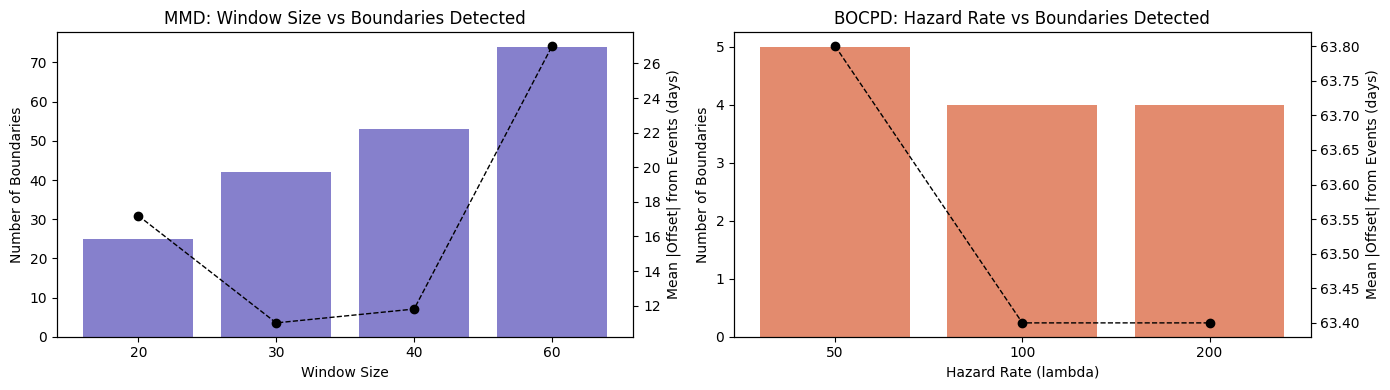

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MMD sweep
axes[0].bar([str(w) for w in mmd_sweep_df["window"]],
            mmd_sweep_df["n_boundaries"], color=COLOR_MMD, alpha=0.7)
axes[0].set_xlabel("Window Size")
axes[0].set_ylabel("Number of Boundaries")
axes[0].set_title("MMD: Window Size vs Boundaries Detected")
ax0_twin = axes[0].twinx()
ax0_twin.plot([str(w) for w in mmd_sweep_df["window"]],
              mmd_sweep_df["mean_abs_offset"], color="black", marker="o",
              linestyle="--", linewidth=1.0)
ax0_twin.set_ylabel("Mean |Offset| from Events (days)")

# BOCPD sweep
axes[1].bar([str(l) for l in bocpd_sweep_df["hazard_lambda"]],
            bocpd_sweep_df["n_boundaries"], color=COLOR_BOCPD, alpha=0.7)
axes[1].set_xlabel("Hazard Rate (lambda)")
axes[1].set_ylabel("Number of Boundaries")
axes[1].set_title("BOCPD: Hazard Rate vs Boundaries Detected")
ax1_twin = axes[1].twinx()
ax1_twin.plot([str(l) for l in bocpd_sweep_df["hazard_lambda"]],
              bocpd_sweep_df["mean_abs_offset"], color="black", marker="o",
              linestyle="--", linewidth=1.0)
ax1_twin.set_ylabel("Mean |Offset| from Events (days)")

plt.tight_layout()
save_fig(fig, "sensitivity_sweeps.png")
plt.show()

---
## S4 -- Comparison and Discussion

### Normalized signal overlay

Both continuous signals (MMD z-score and BOCPD expected run length) min-max
normalized to [0, 1] on the same plot. The BOCPD signal is inverted so that
peaks (short run lengths = likely changepoints) align with MMD z-score peaks.

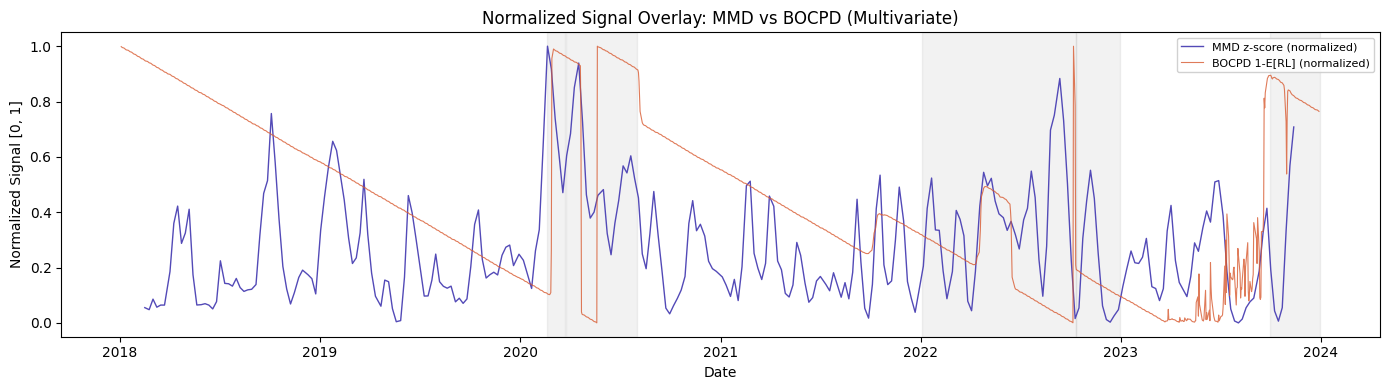

In [15]:
def minmax_normalize(s):
    """Min-max normalize a Series to [0, 1]."""
    smin, smax = s.min(), s.max()
    if smax - smin == 0:
        return s * 0.0
    return (s - smin) / (smax - smin)


# Use multivariate configs as primary comparison
mmd_multi_signal = all_results[3]["continuous_signal"]
bocpd_multi_signal_full = all_results[1]["continuous_signal"]

mmd_norm = minmax_normalize(mmd_multi_signal)
# Invert BOCPD ERL so that changepoints (drops) become peaks
bocpd_norm = 1.0 - minmax_normalize(bocpd_multi_signal_full)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(mmd_norm.index, mmd_norm.values, color=COLOR_MMD, linewidth=1.0,
        label="MMD z-score (normalized)")
ax.plot(bocpd_norm.index, bocpd_norm.values, color=COLOR_BOCPD, linewidth=0.8,
        alpha=0.8, label="BOCPD 1-E[RL] (normalized)")

# Shade known events
for label, (start, end) in KNOWN_EVENTS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color="gray")

ax.set_ylabel("Normalized Signal [0, 1]")
ax.set_xlabel("Date")
ax.set_title("Normalized Signal Overlay: MMD vs BOCPD (Multivariate)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

plt.tight_layout()
save_fig(fig, "normalized_overlay.png")
plt.show()

### Runtime comparison

In [16]:
runtime_df = pd.DataFrame(
    [
        {"Method": r["name"], "Runtime (s)": f"{r['runtime_seconds']:.2f}"}
        for r in all_results
    ]
)
print(runtime_df.to_string(index=False))

            Method Runtime (s)
  BOCPD univariate        5.58
BOCPD multivariate        1.03
    MMD univariate        7.62
  MMD multivariate        8.30


### Assumptions comparison

| Aspect | BOCPD | MMD |
|--------|-------|-----|
| **Distributional assumption** | Gaussian (NIG univariate / NIW multivariate) | None (characteristic kernel) |
| **Online capable** | Yes (by design) | No (requires full windows) |
| **Output type** | P(changepoint) in [0,1] with credible intervals | z-score from permutation null |
| **Key tuning parameters** | Hazard rate lambda, prior hyperparameters | Window size, kernel bandwidth, threshold |
| **Multivariate** | Via NIW (models full covariance) | Native (kernel on feature vectors) |
| **Computational cost** | Fast (closed-form conjugate updates) | Expensive (permutation test per window) |

### Discussion

Commentary below is based on the experimental results above. See the main
panel figure, validation table, and sensitivity sweeps for supporting evidence.

**Feature effect (comparing rows):**

Adding multivariate features (log OHLCV) has opposite effects on the two
methods. For BOCPD, moving from univariate to multivariate *reduces*
sensitivity (9 boundaries down to 4). The NIW model must explain
covariance across 5 dimensions, so only clear distributional shifts
survive the higher-dimensional prior inertia. For MMD, multivariate
input *dramatically increases* sensitivity (1 boundary up to 43). The
RBF kernel naturally captures joint distributional differences across
all features, and the richer signal surface means more windows exhibit
statistically significant MMD statistics. This asymmetry is the most
striking result of the 2x2 design: the same features make a parametric
model more conservative and a nonparametric test more liberal.

**Framework effect (comparing columns):**

On univariate log returns, BOCPD detects 9 change points scattered across
the series while MMD finds only 1 (the COVID crash onset). BOCPD's online
updating means it reacts to any shift in the running mean/variance
estimate, including moderate volatility regime changes in 2018, 2022,
and 2023 that the MMD permutation test does not flag at a z-score
threshold of 10. On multivariate features the picture is more nuanced:
BOCPD multivariate finds 4 boundaries (COVID crash and recovery in 2020,
plus shifts in late 2022 and late 2023), while MMD multivariate finds 43
spread throughout the series. BOCPD's parametric Gaussian assumption
concentrates detections on the sharpest distributional breaks, while
MMD, being distribution-free, treats any detectable difference between
adjacent windows as a potential boundary.

In the validation table, MMD multivariate is the only configuration that
detects all five known events, with offsets generally under 20 trading
days. BOCPD multivariate catches 4 of 5 (missing only the 2022 bottom),
while BOCPD univariate catches 2 of 5 (2022 drawdown and bottom).

**Practical takeaways:**

- **BOCPD is best suited for real-time monitoring** of a univariate signal
  (e.g., streaming returns) where you want calibrated uncertainty and
  credible intervals around each detected change point. With r_max set,
  both univariate (~6s) and multivariate (~1s) are fast on 1500
  observations. The multivariate NIW model is actually faster because
  it detects fewer run lengths to track.

- **MMD multivariate is the strongest offline detector** in this
  comparison, catching all five known events. However, 43 boundaries over
  6 years suggests it may be over-sensitive at a threshold of 10 -- the
  sensitivity sweep shows that boundary count scales with window size
  (25 to 74 boundaries for windows 20 to 60). Practitioners should tune
  the threshold or apply post-hoc filtering (e.g., minimum severity or
  gap constraints).

- **Combining both methods** may be the most robust strategy: use BOCPD
  for real-time alerting (high specificity, low false-positive rate on
  univariate data) and MMD for periodic offline review (high sensitivity,
  catches subtler multivariate shifts that BOCPD misses).

- **The hazard rate sweep** shows BOCPD multivariate is insensitive to
  lambda in the tested range (50-200): it finds 4-5 boundaries with
  ~63 days mean offset from known events. The stability across lambda
  values indicates the NIW model's posterior updates, not the hazard
  prior, are the binding constraint on detection timing.